> ### Public copy (demo data)
>
> The client's 2024 survey cannot be shared publicly, so it is **not in this repository**. Instead,
> `scripts/make_demo_workbook.py` creates `data/raw/engagement_survey_2024.xlsx`, a stand-in file
> with the same structure as the real one: the same sheet name, 22 columns, 42 rows, category
> headers, two 1-10 items and the same delta-from-company-mean format. Only the numbers are
> **invented**.
>
> This means the code, the method and the reasoning below are the originals, but every number,
> table and chart comes from demo data. Phase 1 figures are labelled **DEMO** instead of REAL.
> Where a result depends on the client's numbers, the text says what to look for instead of
> quoting them. Everything the notebooks produce is written to `outputs/`.
>
> To run on the real data, put the client workbook in `data/raw/` and set `data.provenance` to
> `real` in `config/config.yaml`. The labels then switch back.
 

# 05 — Phase 2: The Analytic Pipeline on Synthetic Data

|  |  |
|---|---|
| **Purpose** | Run the pipeline the real data cannot support: construct validation, driver analysis, predictive risk with temporal validation, explainability, personas, trends. |
| **Input** | `data/synthetic/`, the panel that cleared both gates in NB04 |
| **Outputs** | `tab15`–`tab19` · `fig06`, `fig07`, `fig08` |
| **Objectives** | RO2, RO3(b); every result also feeds the 2026 survey redesign (RO4). The refined objectives are defined in the README. |

> 🟠 Everything below is **method demonstration on synthetic data** capability, not company fact.

In [1]:
# Environment setup
import sys
sys.path.insert(0, "../src")

import warnings

# Some numpy/BLAS builds emit spurious "divide by zero / overflow / invalid
# value encountered in matmul" RuntimeWarnings during ordinary matrix
# multiplication inside scikit-learn: floating-point error flags are read
# after the BLAS call and may have been set by BLAS internals. They are
# suppressed here ONLY because the conditions they would warn about are
# checked directly in code: synthetic/models operate on bounded ordinal data,
# and personas.build_personas raises if its standardised matrix is non-finite.
warnings.filterwarnings('ignore', category=RuntimeWarning, message='.*matmul.*')

import numpy as np

np.seterr(divide="ignore", over="ignore", invalid="ignore")

import pandas as pd
import matplotlib.pyplot as plt

from engagement import io, quality, synthetic, models, personas, viz
from engagement.config import load_config, get_seed

cfg = load_config()
SEED = get_seed(cfg)
pd.set_option("display.max_colwidth", 90)
print(f"Config loaded · seed = {SEED}")

Config loaded · seed = 5496


In [2]:
data = pd.read_csv("../data/synthetic/synthetic_panel.csv")
item_map = pd.read_csv("../data/synthetic/synthetic_item_map.csv", index_col=0)
model_df = models.prepare(data, item_map, cfg)
print(f"modelling table: {model_df.shape[0]:,} employee-waves · "
      f"at-risk prevalence {model_df['at_risk'].mean():.1%} "
      f"(threshold = bottom {cfg['models']['risk_threshold_quantile']:.0%} of train-wave engagement)")

modelling table: 3,000 employee-waves · at-risk prevalence 17.0% (threshold = bottom 20% of train-wave engagement)


---
## A. Construct validation

**Decision box**

| | |
|---|---|
| **What** | Cronbach's alpha per construct on harmonised wave-1 items. |
| **Why** | Overlapping questions do not stop a model predicting, but they destabilise its coefficients, so it cannot say which construct matters most, which is exactly the question this phase exists to answer. Each block must therefore be shown to measure one thing before it is used as a separate predictor (Cronbach, 1951). It is also the audit aggregated data made impossible, and how the 2026 scales would be verified. |
| **Rejected** | CFA - the fuller test, but it needs real item-level data; deferred to 2026. |
| **Feeds** | `tab15`; the ≥ 4-items-per-scale rule in the 2026 instrument (NB06). |

In [3]:
cv = models.construct_validation(data, item_map)
cv

,n_items,alpha
construct,,
social,13,0.905
justice,8,0.859
satisfaction,6,0.841
development,6,0.821
balance,3,0.731
engagement,3,0.705
personal,3,0.696
technology,3,0.683
psych_safety,2,0.626


**Read:** read the α column next to the item-count column. The two move together, and that is the
whole lesson. The longer blocks clear the α ≥ .70 convention comfortably. The three-item blocks sit
close to the line. The two-item blocks, psychological safety and ESG, sit clearly below it.

This is by design, not a flaw. The fewer questions a scale has, the less reliable it is. In this
data the true structure is known, so the pattern is easy to see: α falls as the blocks get shorter,
from 0.91 at 13 items to 0.61 at two. That is the evidence behind the four-item minimum in the
2026 survey.

---
## B. Driver analysis

**Decision box**

| | |
|---|---|
| **What** | Standardised OLS of engagement on the eight antecedents, reported with VIF and **Johnson relative weights**. |
| **Why both** | Betas alone mislead when predictors inter-correlate; relative weights split the shared variance (Johnson, 2000). Hakanen et al. (2024) apply the same family of methods to 11,468 employees, arguing they are the appropriate way to weigh predictors that correlate with one another. The two rankings agreeing is the triangulation. |
| **Rejected** | Including `satisfaction`, outcome-adjacent. The Phase 1 IPMA circularity lesson applied forward. |
| **Feeds** | `fig06`, `tab16`|

R² = 0.224


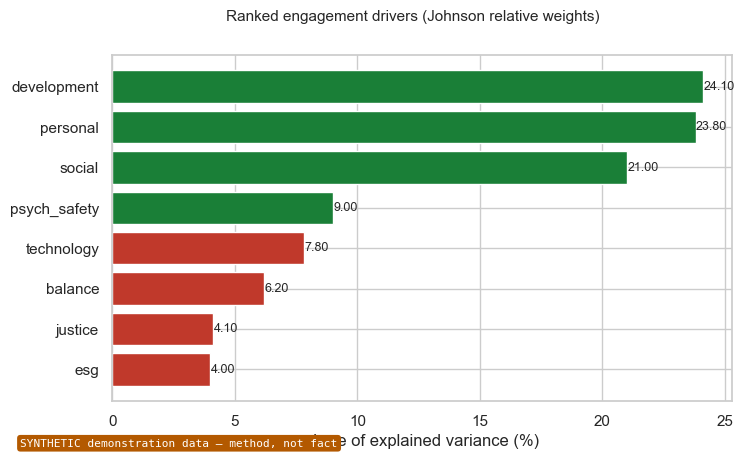

,beta_std,p_value,VIF,relative_weight_%
development,0.190,0.0000,1.25,24.1
personal,0.192,0.0000,1.15,23.8
social,0.162,0.0000,1.32,21.0
psych_safety,0.084,0.0053,1.15,9.0
technology,0.079,0.0090,1.16,7.8
balance,0.066,0.0256,1.11,6.2
justice,-0.020,0.5430,1.32,4.1
esg,0.029,0.3247,1.14,4.0


In [4]:
drivers = models.driver_analysis(model_df[model_df["wave"] == 1])
print(f"R² = {drivers.attrs['r_squared']}")
fig, ax = plt.subplots(figsize=(8, 4.5))
viz.ranked_bar(drivers["relative_weight_%"], ax=ax, xlabel="share of explained variance (%)")
viz.save_figure(fig, "fig06_driver_ranking", cfg, "synthetic",
                "Ranked engagement drivers (Johnson relative weights)")
plt.show()
drivers

**Read:** this is a **recovery test**. It is the reason anything in Phase 2 can be trusted.

The generator was told what the driver weights should be, so the right answer is known in advance.
The question is whether the pipeline finds that answer again, when all it sees is the simulated
survey responses.

Three things to check in the table:

1. **The ranking**, against the weights fed to the generator.
2. **The VIFs.** High values mean the predictors overlap, which would make any ranking arbitrary.
   Here they sit between 1.1 and 1.3, so the ranking is safe to read.
3. **The betas**, against those same weights.

Ignore R² when judging the recovery. It is held down by the measurement error explained in NB04,
not by a bad model.

Then look at where the constructs the 2024 survey never asked about land in the ranking. Personal
resources comes second at 23.8%, psychological safety fifth at 9.0%, technology sixth at 7.8%.
Those are drivers no analysis of the 2024 survey could ever have found, however good the method.
That is what the 2026 redesign rests on.

---
## C. Predictive risk modelling

**Decision box**

| | |
|---|---|
| **What** | Class-weighted logistic baseline vs gradient boosting vs random forest, under **temporal validation**: train waves 1–2, test wave 3. |
| **Why these three** | To test whether complexity is worth it. Logistic regression is the baseline because it is simple and readable; the forest and the boosting model can capture interactions it cannot. A systematic review of 58 turnover-prediction studies found random forest the most widely used of these algorithms and among the most accurate (Talebi et al., 2025). |
| **Why this split** | A random split would put the same employee in train and test. Training on the past and testing on a later wave answers the question actually asked. |
| **Why recall and PR-AUC** | Accuracy is meaningless at this prevalence (printed above; ~17% in this run). The threshold is tuned on **out-of-fold** train probabilities, and selection needs a 60% recall floor before PR-AUC decides. |
| **Rejected** | Deep learning, unjustified for tabular data at this n. |
| **Feeds** | `tab17`, `fig07`|

In [5]:
rm = models.risk_models(model_df, cfg)
print(f"selected on PR-AUC: {rm['best']}  ·  train prevalence {rm['train_prevalence']:.1%}")
rm["metrics"]

selected on PR-AUC: random forest (cross-check)  ·  train prevalence 17.2%


,recall@0.5,precision@0.5,recall@tuned,precision@tuned,pr_auc,roc_auc,brier
model,,,,,,,
logistic (baseline),0.653,0.306,0.719,0.273,0.338,0.738,0.205
random forest (cross-check),0.102,0.680,0.784,0.305,0.446,0.790,0.116
hist gradient boosting,0.437,0.376,0.826,0.266,0.398,0.764,0.143


**Read:** the model is picked on **PR-AUC, not accuracy**. At-risk employees are the minority, so
a model that predicts "fine" for everyone still scores well on accuracy. PR-AUC does not reward
that.

Now compare the two recall columns. The random forest catches 10% of at-risk employees at the
default 0.5 cut-off, and 78% once the threshold is tuned. Same model, same data. Only the cut-off
changed.

That is the deployment point: in retention work, where you set the threshold matters more than
which algorithm you pick. The recommendation is this model at its tuned threshold, re-tuned each
wave.

One more thing. The model trains on waves 1–2 and is tested on wave 3. A random split would put
the same employee on both sides and inflate the score.

**Decision box**

| | |
|---|---|
| **What** | SHAP values for the selected model: what it relies on overall, and how each construct moved one employee's score. |
| **Why** | A random forest has no coefficients to read, and HRM algorithms are criticised precisely because the employee affected cannot see what produced the output (Meijerink et al., 2021). SHAP gives both readings (Lundberg and Lee, 2017), so a flag can be discussed rather than just issued. |
| **Fallback** | If SHAP is unavailable, permutation importance scored on recall is used instead and the substitution is printed, never applied silently. |
| **Feeds** | `tab18`, `fig07`|

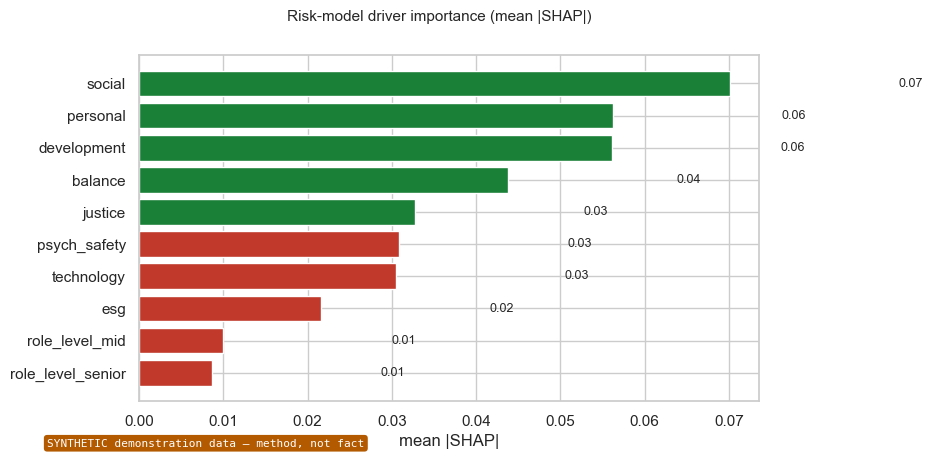

Highest-risk test employee (p = 0.642), construct scores vs workforce (sd):
development    -1.78
esg            -1.46
social         -1.18
personal       -1.08
balance        -0.87
psych_safety   -0.43
justice         0.09
technology      0.74


In [6]:
ex = models.explain(rm, cfg)
imp = ex.get("shap_global", ex["permutation"]).head(10)
src = "mean |SHAP|" if "shap_global" in ex else "permutation importance (recall)"
if "shap_error" in ex: print(ex["shap_error"])
fig, ax = plt.subplots(figsize=(8, 4.5))
viz.ranked_bar(imp.sort_values(), ax=ax, xlabel=src)
viz.save_figure(fig, "fig07_risk_model_importance", cfg, "synthetic",
                f"Risk-model driver importance ({src})")
plt.show()

# one-employee story (always available, SHAP or not): the per-person narrative
print(f"Highest-risk test employee (p = {ex['example_risk_proba']}), construct scores vs workforce (sd):")
print(ex["example_profile"].to_string())

**Read:** three things to take from this.

First, the features the risk model leans on are the same ones the regression ranked first. Two different methods, one answer.

Second, look at the per-employee profile. It lists the constructs that pushed one person's score up, and by how much. The highest-risk employee in the test wave sits 1.78 sd below the workforce on development and 1.46 below on ESG. That is the format a manager can act on: not "this person is at risk", but "this person is at risk, and here is where".

Third, demographics add little once the constructs are in the model. Risk is carried by what a person experiences at work, not by which group they belong to.

---
## D. Personas

**Decision box**

| | |
|---|---|
| **What** | k-means on standardised construct scores; k by the same silhouette-scan-with-singleton-guard as Phase 1, cross-checked against agglomerative clustering (ARI). |
| **Why k-means is allowed here** | n = 1,000. It was rejected at n≈19 in NB03 for instability with same standard, different sample size. |
| **Feeds** | `tab19`|

In [7]:
pr = personas.build_personas(model_df, cfg)
print(f"k = {pr['k']} (silhouette scan below) · hierarchical cross-check ARI = {pr['hierarchical_ari']}")
print(pr["k_scan"].to_string())
pr["profiles"]

k = 2 (silhouette scan below) · hierarchical cross-check ARI = 0.465
   silhouette  smallest_cluster  n_singletons
k                                            
2       0.171               498             0
3       0.102               250             0
4       0.099               237             0
5       0.092               183             0
6       0.092               143             0


,personal,development,social,balance,justice,technology,psych_safety,esg,engagement_score,share_%,risk_rate_%
persona,,,,,,,,,,,
1,0.44,0.48,0.54,0.3,0.54,0.42,0.39,0.38,0.47,50.2,4.0
2,-0.44,-0.48,-0.54,-0.3,-0.54,-0.43,-0.40,-0.38,-0.48,49.8,26.9


In [8]:
print("Work-mode mix per persona (%):")
print(pr["demographics"]["work_mode"].to_string())
print("\nTenure mix per persona (%):")
print(pr["demographics"]["tenure"].to_string())

Work-mode mix per persona (%):
work_mode  hybrid  onsite  remote
persona                          
1            54.6    20.3    25.1
2            56.2    19.3    24.5

Tenure mix per persona (%):
tenure   1-3y  3-5y   <1y   >5y
persona                        
1        39.2  19.1  23.7  17.9
2        40.4  17.7  26.9  15.1


**Read:** this section is held to the same standard as NB03, and it fails that standard in the same way.

Check two numbers. The silhouette is 0.171, below the 0.25 floor used in NB03. The ARI against a hierarchical cross-check is 0.465, so the two clustering methods only half agree on who belongs where. There are no real segments in this data.

What the section does show is the machinery: each persona comes with a risk rate (4.0% against 26.9%) and a demographic mix, in the format a stakeholder would act on. That is a demonstration of what the analysis could produce.

Using one standard in both phases is the point. A project that finds segments only when it needs them has a method problem, not a finding.

---
## E. Trends

**Decision box**

| | |
|---|---|
| **What** | Construct means across the three panel waves. |
| **Why nothing more** | With three waves, anything fancier is false precision. The demonstration is *that* movement becomes measurable at all, which a single 2024 snapshot cannot be. |
| **Feeds** | `fig08`|

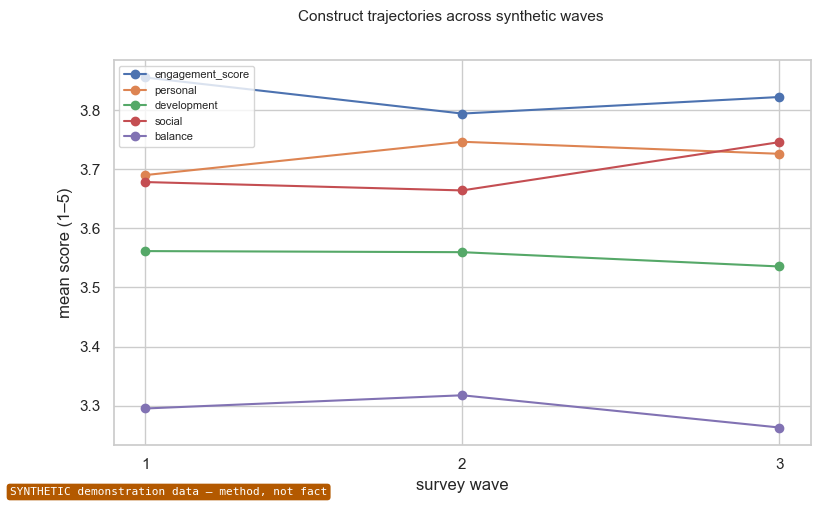

,personal,development,social,balance,justice,technology,psych_safety,esg,engagement_score
wave,,,,,,,,,
1,3.690,3.562,3.678,3.295,3.050,3.808,3.802,3.571,3.855
2,3.746,3.560,3.664,3.318,3.083,3.789,3.882,3.612,3.794
3,3.726,3.536,3.746,3.263,3.064,3.833,3.814,3.555,3.822


In [9]:
cols = models.DRIVER_CONSTRUCTS + ["engagement_score"]
trend = model_df.groupby("wave")[cols].mean()
fig, ax = plt.subplots(figsize=(9, 5))
for c in ["engagement_score", "personal", "development", "social", "balance"]:
    ax.plot(trend.index, trend[c], marker="o", label=c)
ax.set_xticks(trend.index); ax.set_xlabel("survey wave"); ax.set_ylabel("mean score (1–5)")
ax.legend(fontsize=8)
viz.save_figure(fig, "fig08_wave_trends", cfg, "synthetic",
                "Construct trajectories across synthetic waves")
plt.show()
trend.round(3)

In [10]:
from pathlib import Path
t = Path(cfg["paths"]["tables_dir"])
cv.to_csv(t / "tab15_construct_reliability.csv")
drivers.to_csv(t / "tab16_driver_ranking.csv")
rm["metrics"].to_csv(t / "tab17_risk_model_comparison.csv")
imp.to_csv(t / "tab18_risk_importance.csv")
pr["profiles"].to_csv(t / "tab19_personas.csv")
print("tables tab15–tab19 written")

tables tab15–tab19 written


---
## Handover

Five capabilities demonstrated: reliability, drivers, individual risk, segments, trends, each
impossible on the 2024 aggregates. NB06 computes that contrast (`synthesis.capability_comparison`)
rather than restating it here.

**All capability on synthetic data; none of it a fact about AccessFintech's workforce.**

**Next:** `06_phase3_synthesis.ipynb`.

---
## References

Cronbach, L.J. (1951) 'Coefficient alpha and the internal structure of tests',
*Psychometrika*, 16(3), pp. 297–334.

Hakanen, J.J., Bakker, A.B. and Turunen, J. (2024) 'The relative importance of various job
resources for work engagement: a concurrent and follow-up dominance analysis',
*BRQ Business Research Quarterly*, 27(3). doi:10.1177/23409444211012419.

Johnson, J.W. (2000) 'A heuristic method for estimating the relative weight of predictor
variables in multiple regression', *Multivariate Behavioral Research*, 35(1), pp. 1–19.

Kaufman, L. and Rousseeuw, P.J. (1990) *Finding groups in data: an introduction to cluster
analysis*. New York: Wiley.

Lundberg, S.M. and Lee, S.-I. (2017) 'A unified approach to interpreting model predictions',
*Advances in Neural Information Processing Systems*, 30, pp. 4765–4774.

Meijerink, J., Boons, M., Keegan, A. and Marler, J. (2021) 'Algorithmic human resource
management: synthesising developments and cross-disciplinary insights', *International
Journal of Human Resource Management*, 32(12), pp. 2545–2562.

Talebi, H., Khatibi Bardsiri, A. and Khatibi Bardsiri, V. (2025) 'Machine learning approaches
for predicting employee turnover: a systematic review', *Engineering Reports*, 7, e70298.
doi:10.1002/eng2.70298.